# Two-Body Weber Electrodynamics

Demonstration of the WeberElectrodynamics.jl API for simulating charged particle dynamics.

## Weber Hamiltonian

For $N$ charged particles, the Weber Hamiltonian is:

$$H = \sum_i \frac{|\mathbf{p}_i|^2}{2m_i} + \sum_{i<j} U_{ij}$$

where the Weber potential between particles $i$ and $j$ is:

$$U_{ij} = \frac{q_i q_j}{r_{ij}} \left(1 - \frac{\dot{r}_{ij}^2}{2c^2}\right)$$

Here $r_{ij} = |\mathbf{r}_i - \mathbf{r}_j|$ is the separation distance and $\dot{r}_{ij}$ is the radial velocity:

$$\dot{r}_{ij} = \frac{(\mathbf{r}_i - \mathbf{r}_j) \cdot (\mathbf{v}_i - \mathbf{v}_j)}{r_{ij}}$$

The velocity-dependent term causes **orbital precession** analogous to relativistic effects in General Relativity.

In [1]:
using WeberElectrodynamics
using Plots
using Printf

[ Info: Precompiling WeberElectrodynamics [b7b438b0-8b51-4018-ba50-da6ecf296240] (cache misses: include_dependency fsize change (4), mismatched flags (16))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling WeberElectrodynamicsPlotsExt [fea4dfcb-c607-547a-9a66-e01c73208f10] (cache misses: wrong dep version loaded (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## 1. System Construction

Create a `WeberSystem` for two particles in 2D. The system is purely symbolic - physical parameters (masses, charges, c) are specified when creating the problem.

In [2]:
# Physical parameters
m1, m2 = 1.0, 0.1       # masses
q1, q2 = 0.316, -0.316  # charges (q1*q2 ~ -0.1, attractive)
c = 4.0                 # speed of light
k = q1 * q2             # coupling constant

# Build the system (purely symbolic)
system = WeberSystem(2, 2)

println("Particles: ", system.n_particles)
println("Dimensions: ", system.dims)
println("Degrees of freedom: ", system.degrees_of_freedom)

Particles: 2
Dimensions: 2
Degrees of freedom: 4


## 2. Symbolic Hamiltonian

The `WeberSystem` stores the symbolic Hamiltonian and equations of motion for inspection and LaTeX export.

In [3]:
system.hamiltonian_symbolic

(q1*q2*(1 + (-((((x1 - x2)*((-px2) / m2 + px1 / m1) + (y1 - y2)*(py1 / m1 + (-py2) / m2)) / sqrt((x1 - x2)^2 + (y1 - y2)^2))^2)) / (2(c^2)))) / sqrt((x1 - x2)^2 + (y1 - y2)^2) + (px2^2 + py2^2) / (2m2) + (px1^2 + py1^2) / (2m1)

In [4]:
system.dp_dt_symbolic[1]  # Force on particle 1, x-component

-((-q1*q2*(x1 - x2)*(1 + (-((((x1 - x2)*((-px2) / m2 + px1 / m1) + (y1 - y2)*(py1 / m1 + (-py2) / m2)) / sqrt((x1 - x2)^2 + (y1 - y2)^2))^2)) / (2(c^2)))) / (((x1 - x2)^2 + (y1 - y2)^2)*sqrt((x1 - x2)^2 + (y1 - y2)^2))) - ((-q1*q2*((x1 - x2)*((-px2) / m2 + px1 / m1) + (y1 - y2)*(py1 / m1 + (-py2) / m2))*((-(x1 - x2)*((x1 - x2)*((-px2) / m2 + px1 / m1) + (y1 - y2)*(py1 / m1 + (-py2) / m2))) / (((x1 - x2)^2 + (y1 - y2)^2)*sqrt((x1 - x2)^2 + (y1 - y2)^2)) + ((-px2) / m2 + px1 / m1) / sqrt((x1 - x2)^2 + (y1 - y2)^2))) / ((c^2)*((x1 - x2)^2 + (y1 - y2)^2)))

In [5]:
system.dq_dt_symbolic[1]  # Velocity of particle 1, x-component

(-q1*q2*(x1 - x2)*((x1 - x2)*((-px2) / m2 + px1 / m1) + (y1 - y2)*(py1 / m1 + (-py2) / m2))) / ((c^2)*m1*(sqrt((x1 - x2)^2 + (y1 - y2)^2)^3)) + px1 / m1

## 3. Problem Setup

Set up initial conditions for a slightly elliptical orbit in the center-of-mass frame.

In [6]:
# Orbital parameters
r0 = 2.0                           # initial separation
M = m1 + m2                        # total mass
mu = m1 * m2 / M                   # reduced mass
v_circ = sqrt(abs(k) / (mu * r0))  # circular orbit velocity
v_scale = 0.9                      # sub-circular for ellipticity

# Center-of-mass frame positions
q0 = [-m2/M * r0, 0.0, m1/M * r0, 0.0]

# Momenta for elliptical orbit
p0 = [0.0, m1 * (-m2/M * v_circ * v_scale),
      0.0, m2 * (m1/M * v_circ * v_scale)]

# Simulation time (multiple orbits to see precession)
T_orbit = 2pi * sqrt(r0^3 * mu / abs(k))
tspan = (0.0, 5 * T_orbit)

println("Orbital period: ", round(T_orbit, digits=2))
println("Simulation time: ", round(tspan[2], digits=2), " (5 orbits)")

Orbital period: 16.96
Simulation time: 84.78 (5 orbits)


In [7]:
prob = WeberProblem(system, tspan, q0, p0;
    masses=[m1, m2], charges=[q1, q2], c=c, dt=0.001)

WeberProblem(WeberSystem(2 particles, 2D, 4 DOF), (0.0, 84.78351952441355), [-0.18181818181818182, 0.0, 1.8181818181818181, 0.0], [0.0, -0.060634283731535614, 0.0, 0.060634283731535614], [1.0, 0.1], [0.316, -0.316], 4.0, [1.0, 0.1, 0.316, -0.316, 4.0], 0.001, 1.0e-13, 100)

## 4. Integration

Solve using the CommonSolve interface. The package uses a symplectic integrator internally.

In [8]:
sol = solve(prob)

println("Return code: ", sol.retcode)
println("Time steps: ", length(sol.t))

Return code: Success
Time steps: 84785

Time steps: 84785


### Stepped Integration

For fine-grained control, use `init`, `step!`, and `solve!`.

In [9]:
integrator = init(prob)

# Step manually
for _ in 1:10
    step!(integrator)
end
println("After 10 steps: t = ", round(integrator.t, digits=4))

# Complete the integration
sol_stepped = solve!(integrator)
println("Final time: ", round(sol_stepped.t[end], digits=2))

After 10 steps: t = 0.01
Final time: 84.78
84.78


## 5. Trajectory Analysis

Extract and plot particle trajectories.

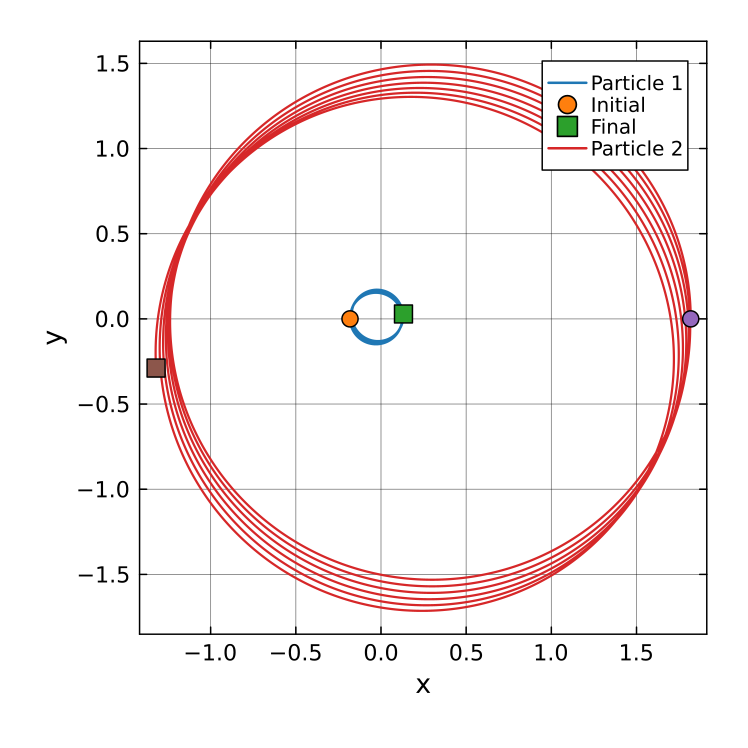

In [10]:
traj = compute_trajectory_data(sol, 2, 2; stride=10)
plot_trajectories(traj)

## 6. Energy Conservation

Verify symplectic integration preserves energy.

In [11]:
# Define energy functions (signature: q, p, params)
function total_energy(q, p, params)
    KE = (p[1]^2 + p[2]^2)/(2m1) + (p[3]^2 + p[4]^2)/(2m2)
    dx, dy = q[1] - q[3], q[2] - q[4]
    r = sqrt(dx^2 + dy^2)
    vx1, vy1, vx2, vy2 = p[1]/m1, p[2]/m1, p[3]/m2, p[4]/m2
    rdot = (dx*(vx1-vx2) + dy*(vy1-vy2)) / r
    PE = k / r * (1 - rdot^2 / (2*c^2))
    KE + PE
end

kinetic_energy(q, p, params) = (p[1]^2 + p[2]^2)/(2m1) + (p[3]^2 + p[4]^2)/(2m2)
potential_energy(q, p, params) = total_energy(q, p, params) - kinetic_energy(q, p, params)

energy = compute_energy_timeseries(sol, total_energy, kinetic_energy, potential_energy, nothing; stride=10)

println("Max local error: ", @sprintf("%.2e", energy.max_local_error))
println("Relative energy range: ", @sprintf("%.2e", energy.relative_energy_range))

Max local error: 1.20e-09
Relative energy range: -4.04e-08


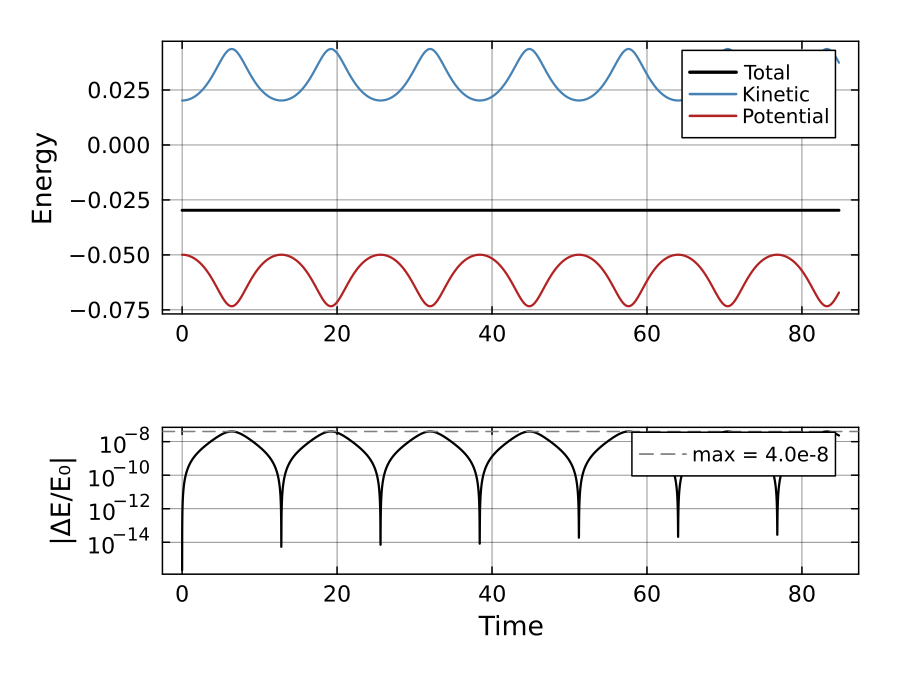

In [12]:
plot_energy(energy)

## 7. Force Analysis

Compute pairwise forces and verify Newton's third law.

Newton's 3rd law max violation: 0.00e+00


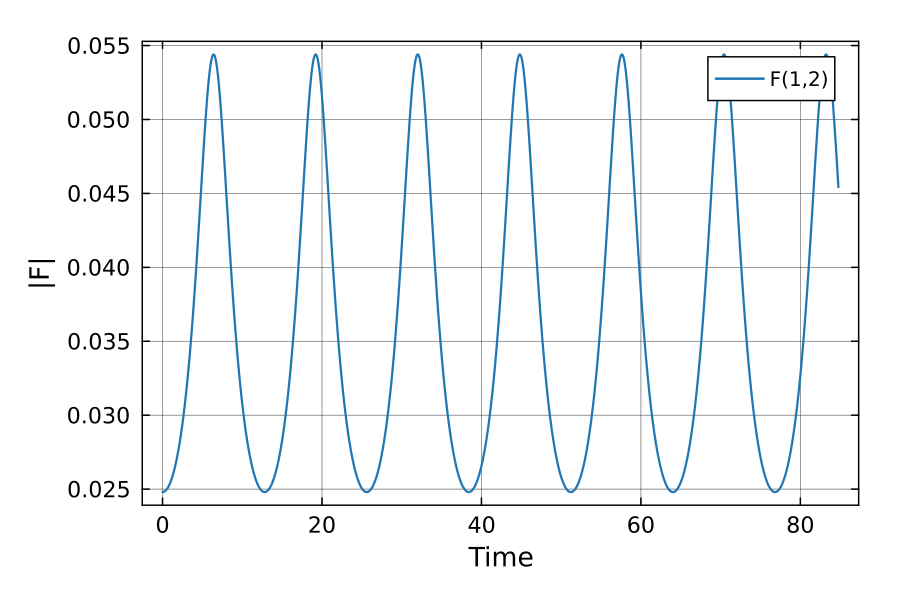

In [13]:
forces = compute_force_timeseries(sol, 2, 2, [m1, m2], [q1, q2], c; stride=10)

n3 = check_newtons_third_law(forces)
println("Newton's 3rd law max violation: ", @sprintf("%.2e", n3.global_max_violation))

plot_forces(forces)

## 8. Phase Space

Analyze the relative motion in $(r, \dot{r})$ phase space.

Min separation: 1.361
Max separation: 2.0


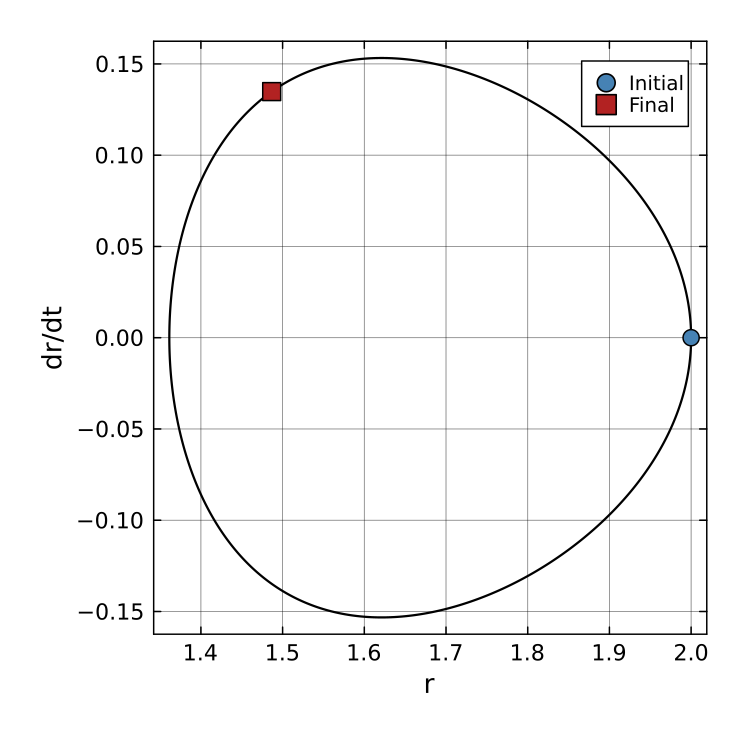

In [14]:
ps = compute_phase_space_data(sol, 2, 2, [m1, m2]; stride=10)

println("Min separation: ", round(minimum(ps.separation_distance), digits=3))
println("Max separation: ", round(maximum(ps.separation_distance), digits=3))

plot_phase_space(ps)

## API Summary

| Category | Types | Functions |
|----------|-------|-----------|
| **System** | `WeberSystem` | - |
| **Problem** | `WeberProblem` | - |
| **Solution** | `WeberSolution`, `WeberIntegrator` | `solve`, `init`, `step!`, `solve!` |
| **Trajectories** | `TrajectoryData` | `compute_trajectory_data`, `plot_trajectories` |
| **Energy** | `EnergyData` | `compute_energy_timeseries`, `plot_energy` |
| **Forces** | `ForceData`, `NewtonsThirdLawData` | `compute_force_timeseries`, `check_newtons_third_law`, `plot_forces` |
| **Phase Space** | `PhaseSpaceData` | `compute_phase_space_data`, `plot_phase_space` |